# Superstore Analysis For Business Insights

# ✅ STEP 0: Understand The Business Problem (Most Important)

## Business Questions

1. What drives profitability?
2. How does discount impact profit?
3. Which segments/categories generate the most value?

    
## - What decision will be made using this analysis?

1- By this analysis we could know from which city and state we are getting most of our customers and what offers we can give them to retain them and from which state and region we need to focus more and what type of offers we can give them so they purchase more product from us.

2- Which product is sold more and from which category it belongs so we can increase thier quantity so we never do out of stock and if these product are getting sold very much we can increase thier price so we can get more profit. products which are not getting sold and don't have much hype so we can give more discounts on them to sold them asap and don't buy thier stock as much we useed to do to descrese our loss.

3- With this analysis we can know in which region we have  most of the customers and accoding to that we need to generates our online ads and discount offers.

4 - With this we can know what are the top customers and what special offers we need to give them.

Is profit margin already high?

Is discount affecting sales?

Is demand price sensitive?
    
## - Who is the stakeholder?

here stake holder is a Regional Manager who manages the store and takes all the decision.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [3]:
df = pd.read_excel(r"C:\DA_Questions\Excel\Superstore.xlsx")
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-152156,2022-03-22,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,West,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,West,FUR-CH-10000454,Furniture,Fasteners,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


## ✅ STEP 1: Understand Data Structure (Data Types)

In [4]:


# First technical step.

# You check:

# - What columns exist?

df.columns.tolist()
    

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [5]:
df.shape

(9994, 21)

In [6]:
# - What are data types?
    
# - Which are categorical?
    
# - Which are numerical?
    
# - Date columns?
    
# - ID columns?

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9987 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

In [7]:
# Time range
df['Order Date'].min(), df['Order Date'].max()

(Timestamp('2019-01-02 00:00:00'), Timestamp('2022-12-31 00:00:00'))

## Data Cleaning & Quality Check (THIS IS WHERE IT FITS)


In [8]:

### 1️⃣ Check Missing Values

df.isnull().sum()
    
# - Decide: drop / fill / keep
    



Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       7
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [9]:
df = df.dropna(subset=['Postal Code'])          # drop first
df['Postal Code'] = df['Postal Code'].astype('Int64').astype(str)  # then convert

In [10]:
### 2️⃣ Check Duplicates

df.duplicated().sum()
    
# - Remove if needed

np.int64(0)

No missing values or duplicate records were found.

## Feature Engineering

In [11]:

df['Shipping Time'] = df['Ship Date'] - df['Order Date']
df['Shipping Time'].reset_index()    


,index,Shipping Time
0,0,-496 days
1,1,3 days
2,2,4 days
3,3,7 days
4,4,7 days
...,...,...
9982,9989,2 days
9983,9990,5 days
9984,9991,5 days
9985,9992,5 days


In [12]:
# Flag and investigate anomalies
invalid_shipping = df[df['Shipping Time'].dt.days < 0]
print(f"Rows with negative shipping time: {len(invalid_shipping)}")
df = df[df['Shipping Time'].dt.days >= 0]  # then decide to drop
df.head()

Rows with negative shipping time: 54


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Time
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,West,FUR-CH-10000454,Furniture,Fasteners,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3 days
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Fasteners,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4 days
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,West,FUR-TA-10000577,Furniture,Fasteners,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7 days
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,West,OFF-ST-10000760,Office Supplies,Fasteners,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7 days
5,6,CA-2018-115812,2022-06-09,2022-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,FUR-FU-10001487,Furniture,Fasteners,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,5 days


In [13]:
df['Revenue'] = df['Sales'] * df['Quantity']
df['Revenue']

1       2195.8200
2         29.2400
3       4787.8875
4         44.7360
5        342.0200
          ...    
9989      75.7440
9990     183.9200
9991     517.1520
9992     118.4000
9993     486.3200
Name: Revenue, Length: 9933, dtype: float64

In [14]:
# - Profit Margin = Profit / Sales

df['Profit Margin'] = df['Profit'] / df['Sales']
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Time,Revenue,Profit Margin
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Fasteners,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,3 days,2195.82,0.30
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Fasteners,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,4 days,29.24,0.47


In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Year'] = df['Order Date'].dt.year
df['Order Year'].reset_index()
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Time,Revenue,Profit Margin,Order Year
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Fasteners,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,3 days,2195.82,0.30,2020
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Fasteners,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,4 days,29.24,0.47,2020


In [16]:
df['Order Month'] = df['Order Date'].dt.month
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product Name,Sales,Quantity,Discount,Profit,Shipping Time,Revenue,Profit Margin,Order Year,Order Month
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,3 days,2195.82,0.30,2020,11
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,4 days,29.24,0.47,2020,6


In [17]:
df['Order Quarter'] = df['Order Date'].dt.quarter 
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sales,Quantity,Discount,Profit,Shipping Time,Revenue,Profit Margin,Order Year,Order Month,Order Quarter
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.94,3,0.0,219.5820,3 days,2195.82,0.30,2020,11,4
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.62,2,0.0,6.8714,4 days,29.24,0.47,2020,6,2


In [18]:
df['Loss_Order'] = df['Profit'] < 0
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Quantity,Discount,Profit,Shipping Time,Revenue,Profit Margin,Order Year,Order Month,Order Quarter,Loss_Order
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,3 days,2195.8200,0.3000,2020,11,4,False
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,4 days,29.2400,0.4700,2020,6,2,False
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,7 days,4787.8875,-0.4000,2019,10,4,True
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,7 days,44.7360,0.1125,2019,10,4,False
5,6,CA-2018-115812,2022-06-09,2022-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,7,0.00,14.1694,5 days,342.0200,0.2900,2022,6,2,False


# ✅ STEP 2: Basic Summary Statistics

In [19]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Time,Revenue,Profit Margin,Order Year,Order Month,Order Quarter
count,9933.000000,9933,9933,9933.000000,9933.000000,9933.000000,9933.000000,9933,9933.000000,9933.000000,9933.000000,9933.000000,9933.000000
mean,4993.244941,2021-02-11 22:36:03.696768512,2021-02-15 21:32:16.454243328,229.012625,3.786771,0.156467,28.395771,3 days 22:56:12.757475083,1143.907085,0.120077,2020.512534,7.788382,2.876573
min,2.000000,2019-01-02 00:00:00,2019-01-04 00:00:00,0.444000,1.000000,0.000000,-6599.978000,0 days 00:00:00,0.444000,-2.750000,2019.000000,1.000000,1.000000
25%,2494.000000,2020-04-08 00:00:00,2020-04-14 00:00:00,17.216000,2.000000,0.000000,1.724800,3 days 00:00:00,48.480000,0.075000,2020.000000,5.000000,2.000000
50%,4995.000000,2021-03-04 00:00:00,2021-03-08 00:00:00,54.320000,3.000000,0.200000,8.601600,4 days 00:00:00,182.520000,0.270000,2021.000000,9.000000,3.000000
75%,7488.000000,2021-11-24 00:00:00,2021-11-28 00:00:00,209.700000,5.000000,0.200000,29.271600,5 days 00:00:00,761.200000,0.362500,2021.000000,11.000000,4.000000
max,9994.000000,2022-12-31 00:00:00,2022-12-31 00:00:00,22638.480000,14.000000,0.800000,8399.976000,7 days 00:00:00,135830.880000,0.500000,2022.000000,12.000000,4.000000
std,2885.469315,NaN,NaN,622.773577,2.225199,0.206554,234.454682,1 days 17:57:50.101651470,3895.457051,0.467161,1.031213,3.277309,1.057389


In [20]:
df.describe(include = 'object')

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
count,9933,9933,9933,9933,9933,9933,9933,9933,9933,9933,9933,9933,9933,9933
unique,4979,4,793,793,3,1,529,49,628,4,1861,3,17,1848
top,CA-2021-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,10035,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,5926,37,37,5171,9933,910,1988,259,3198,19,5997,1517,47


In [21]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Quantity,Discount,Profit,Shipping Time,Revenue,Profit Margin,Order Year,Order Month,Order Quarter,Loss_Order
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.0,219.5820,3 days,2195.82,0.30,2020,11,4,False
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.0,6.8714,4 days,29.24,0.47,2020,6,2,False


In [22]:
df[['Sales','Profit','Discount','Quantity']].agg(['mean','median','std','skew']).round(2)

,Sales,Profit,Discount,Quantity
mean,229.01,28.40,0.16,3.79
median,54.32,8.60,0.20,3.00
std,622.77,234.45,0.21,2.23
skew,13.05,7.58,1.68,1.28


In [23]:
sales_stats = df['Sales'].agg(['mean','median','std','skew']).round(2)
sales_stats.reset_index()

,index,Sales
0,mean,229.01
1,median,54.32
2,std,622.77
3,skew,13.05


## 🔷 Sales – Statistical Summary

**Mean:** 229.86  
**Median:** 54.49  
**Standard Deviation:** 623.25  
**Skewness:** 12.97  

### Key Observations

- Mean is significantly higher than median.
- Extremely high positive skew (12.97).
- Large standard deviation indicates high variability.

### Interpretation

Sales distribution is **highly right-skewed**.  
Most transactions are low-value, while a small number of very large orders inflate the average.

The **median (54.49)** better represents a typical transaction than the mean.

This suggests revenue concentration among a small number of high-value orders.

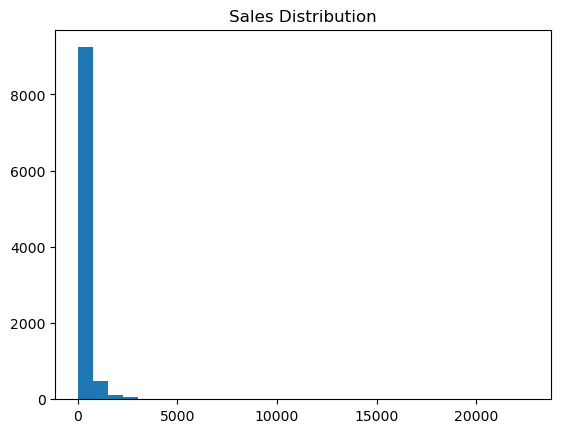

In [24]:
plt.hist(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

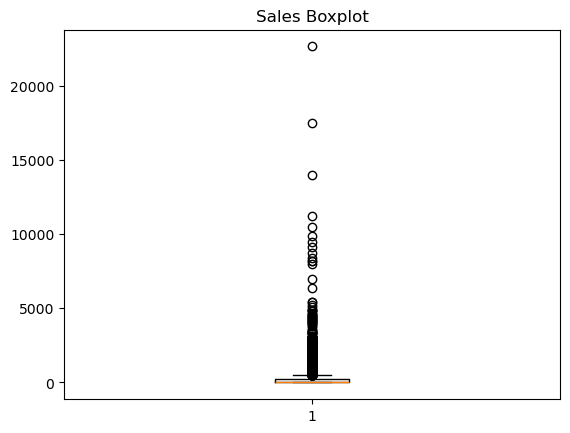

In [25]:
plt.boxplot(df['Sales'])
plt.title("Sales Boxplot")
plt.show()

In [26]:
profit_stats = df['Profit'].agg(['mean','median','std','skew']).round(2)
profit_stats.reset_index()

,index,Profit
0,mean,28.40
1,median,8.60
2,std,234.45
3,skew,7.58


In [27]:
# This one line does all the counting and dividing for you
percentage_zeros = (df['Profit'] == 0).mean() * 100

print(f"Percentage of exact zero profit: {percentage_zeros}%")

Percentage of exact zero profit: 0.6543843753146079%


## 🔷 Profit – Statistical Summary

**Mean:** 28.66  
**Median:** 8.67  
**Standard Deviation:** 234.26  
**Skewness:** 7.56  

### Key Observations

- Mean is significantly higher than median.
- High positive skew (7.56 ).
- Large standard deviation indicates high variability.

### Interpretation

Profit distribution is **Right-skewed**.

Most orders generate small profit, but a few generate extremely high profits.

Also, since Superstore usually contains negative profit orders, there may be extreme losses affecting distribution.

Profit variability is very high.

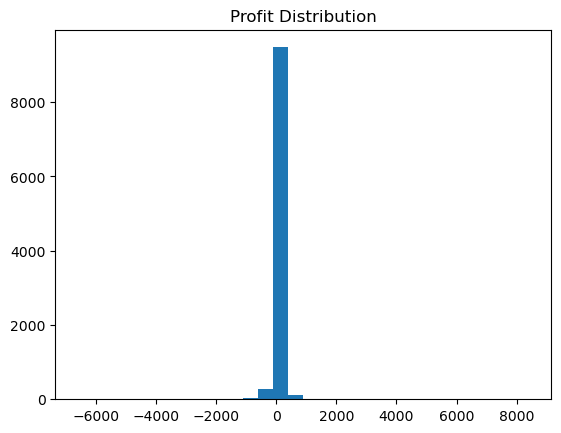

In [28]:
plt.hist(df['Profit'], bins=30)
plt.title("Profit Distribution")
plt.show()

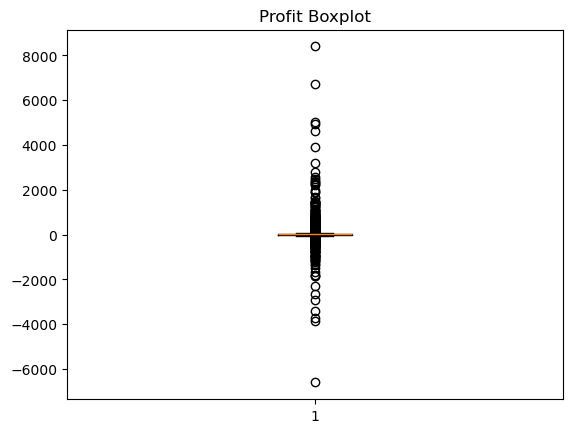

In [29]:
plt.boxplot(df['Profit'])
plt.title("Profit Boxplot")
plt.show()

In [30]:
discount_stats = df['Discount'].agg(['mean','median','std','skew']).round(2)
discount_stats.reset_index()

,index,Discount
0,mean,0.16
1,median,0.20
2,std,0.21
3,skew,1.68


## 🔷 Discount – Statistical Summary

**Mean:** 0.16  
**Median:** 0.20  
**Standard Deviation:** 0.21  
**Skewness:** 1.68  

### Key Observations

- Slight difference between mean and median.
- Positive skew (1.68).

### Interpretation

Most transactions have low to moderate discounts, but some receive very high discounts.

Discount distribution is skewed but not as extreme as Sales or Profit.

This could explain profit variability.

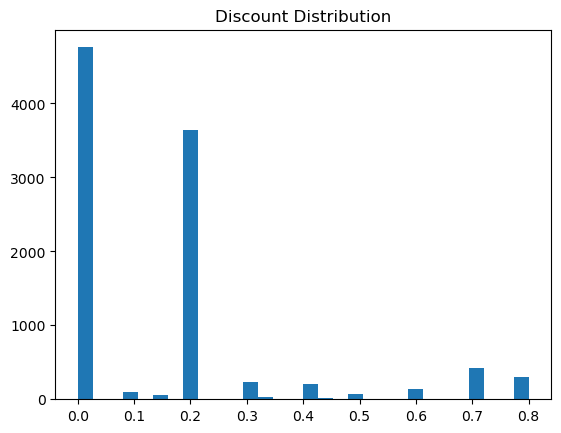

In [31]:
plt.hist(df['Discount'], bins=30)
plt.title("Discount Distribution")
plt.show()

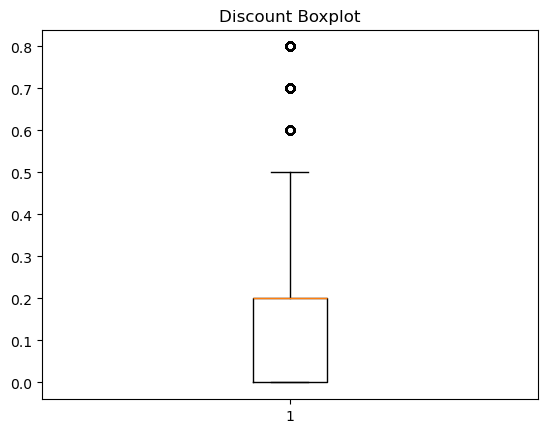

In [32]:
plt.boxplot(df['Discount'])
plt.title("Discount Boxplot")
plt.show()

In [33]:
quantity_stats = df['Quantity'].agg(['mean','median','std','skew']).round(2)
quantity_stats.reset_index()

,index,Quantity
0,mean,3.79
1,median,3.00
2,std,2.23
3,skew,1.28


## 🔷 Quantity – Statistical Summary

**Mean:** 3.79  
**Median:** 3.00  
**Standard Deviation:** 2.23  
**Skewness:** 1.28  

### Key Observations

- Mean (3.79) and Median (3.0) are relatively close, meaning no extreme outliers are heavily distorting the average.

- Skewness of 1.28 indicates a moderate positive skew.

- Standard deviation of 2.23 is moderate relative to the mean, showing controlled variability.

### Interpretation

Most orders contain between 1 to 5 items, which is the typical purchase behavior for retail customers. A small number of bulk orders pull the distribution slightly to the right, causing the moderate skew.
Unlike Sales and Profit (which were heavily skewed), Quantity is the most "normal-looking" of the four variables, meaning customer purchase quantities are fairly consistent and predictable.

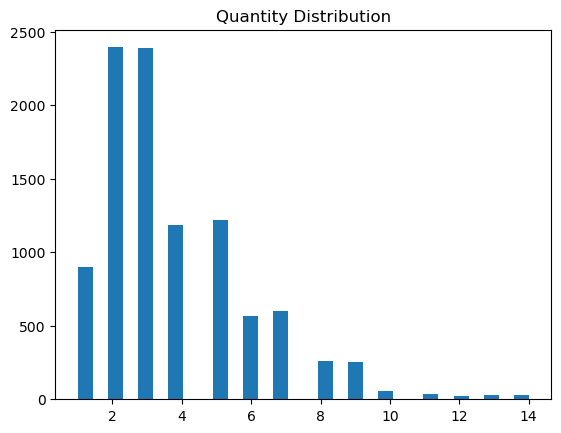

In [34]:
plt.hist(df['Quantity'], bins=30)
plt.title("Quantity Distribution")
plt.show()

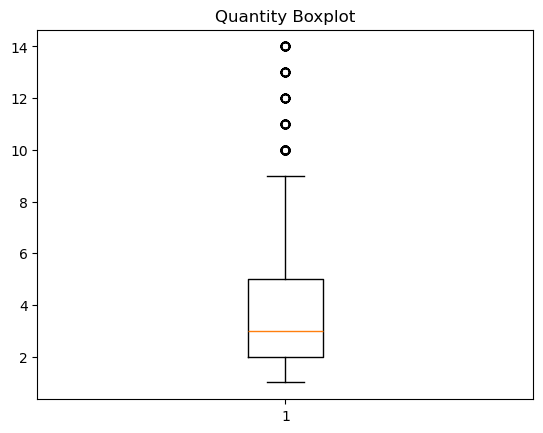

In [35]:
plt.boxplot(df['Quantity'])
plt.title("Quantity Boxplot")
plt.show()

## Statistical Summary Interpretation

Sales and Profit distributions are highly positively skewed, with skewness values of 12.97 and 7.56 respectively. In both cases, the mean is significantly higher than the median, indicating the presence of extreme high-value transactions that distort the average. This suggests that revenue and profit are concentrated among a small number of large orders.

Discount also shows positive skewness (1.68), indicating that while most transactions have low to moderate discounts, a subset receives high discounts which may impact profitability.

Quantity shows relatively lower skewness (1.28) and closer mean-median values, indicating more consistent ordering patterns compared to financial metrics.

Due to extreme skewness in Sales and Profit, median is a more reliable measure of central tendency than mean for representing a typical transaction.

## ✅ STEP 3: Distribution Analysis

In [36]:
df['Category'].value_counts().reset_index()


,Category,count
0,Office Supplies,5997
1,Furniture,2107
2,Technology,1829


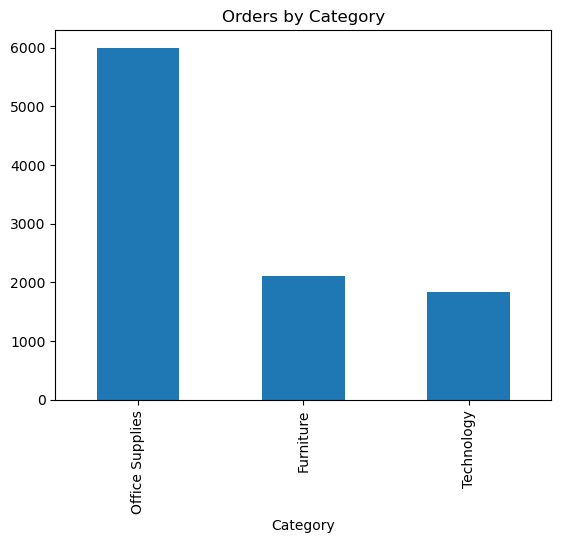

In [37]:
df['Category'].value_counts().plot(kind='bar')
plt.title("Orders by Category")
plt.show()

In [38]:
df['Segment'].value_counts()


Segment
Consumer       5171
Corporate      2988
Home Office    1774
Name: count, dtype: int64

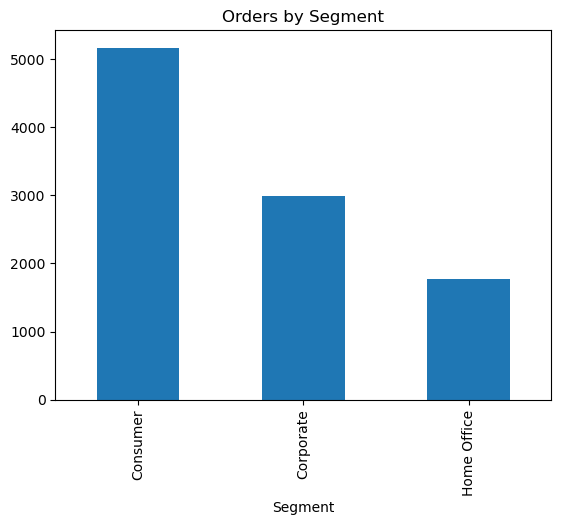

In [39]:
df['Segment'].value_counts().plot(kind='bar')
plt.title("Orders by Segment")
plt.show()

In [40]:
df['Region'].value_counts()

Region
West       3198
East       2818
Central    2308
South      1609
Name: count, dtype: int64

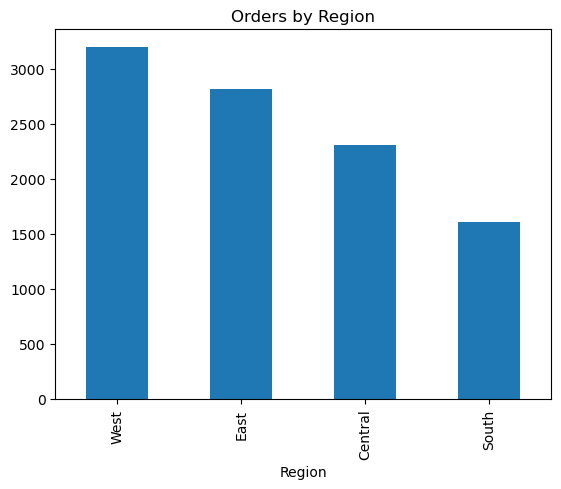

In [41]:
df['Region'].value_counts().plot(kind='bar')
plt.title("Orders by Region")
plt.show()

# RELATIONSHIP ANALYSIS (Phase 2)


In [42]:
df[df['Loss_Order']].groupby('Sub-Category')['Profit'].sum().sort_values().head(10).reset_index()

,Sub-Category,Profit
0,Binders,-38046.8513
1,Tables,-31837.0705
2,Machines,-30118.6682
3,Bookcases,-12152.2060
4,Chairs,-9880.8413
5,Appliances,-8505.7832
6,Phones,-7474.5364
7,Furnishings,-6417.2046
8,Storage,-6392.3910
9,Supplies,-3015.6219


In [43]:
top_customers = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10).reset_index()
top_customers

,Customer Name,Profit
0,Tamara Chand,8785.3431
1,Raymond Buch,6976.0959
2,Sanjit Chand,5757.4119
3,Hunter Lopez,5622.4292
4,Adrian Barton,5444.8055
5,Tom Ashbrook,4703.7883
6,Christopher Martinez,3899.8904
7,Keith Dawkins,3038.6254
8,Andy Reiter,2884.6208
9,Daniel Raglin,2869.0760


In [44]:
df.groupby('Order Year')[['Sales','Profit']].sum().reset_index()

,Order Year,Sales,Profit
0,2019,465412.4090,60426.6767
1,2020,605976.5780,80964.1853
2,2021,733010.2252,93371.6097
3,2022,470383.1931,47292.7255


In [45]:
# Step 1: Create the bucket (include_lowest fixes the null issue)
df['Discount Bucket'] = pd.cut(df['Discount'], 
                                bins=[0, 0.1, 0.2, 0.4, 0.8], 
                                labels=['Low','Medium','High','Very High'],
                                include_lowest=True)

# Step 2: See the numbers first
df.groupby('Discount Bucket', observed=True)['Profit'].mean().round(2).reset_index()

,Discount Bucket,Profit
0,Low,67.06
1,Medium,24.69
2,High,-77.67
3,Very High,-106.61


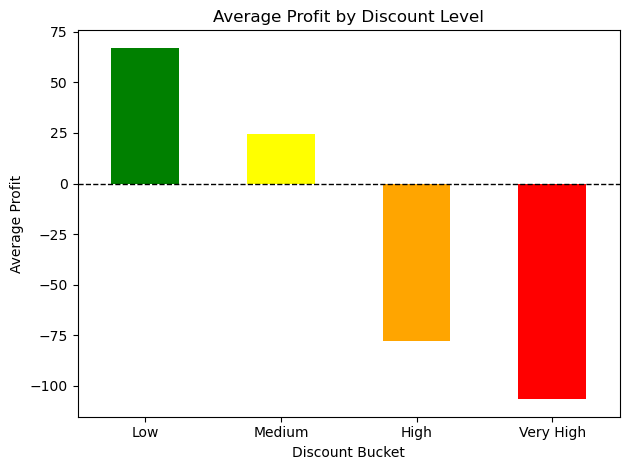

In [46]:
# Step 3: Then plot it
df.groupby('Discount Bucket', observed=True)['Profit'].mean().round(2).plot(kind='bar', color=['green','yellow','orange','red'])
plt.title("Average Profit by Discount Level")
plt.xlabel("Discount Bucket")
plt.ylabel("Average Profit")
plt.axhline(0, color='black', linewidth=1, linestyle='--')  # zero line so you can see where loss starts
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

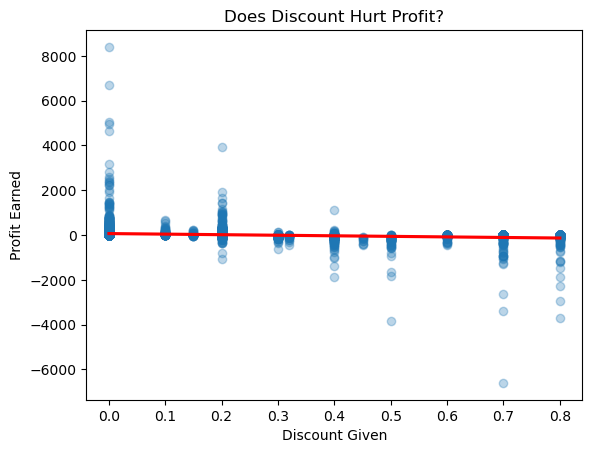

In [47]:
sns.regplot(x='Discount', y='Profit', data=df, 
            scatter_kws={'alpha': 0.3},   # makes dots semi-transparent so overlaps are visible
            line_kws={'color': 'red'})    # trend line in red

plt.title("Does Discount Hurt Profit?")
plt.xlabel("Discount Given")
plt.ylabel("Profit Earned")
plt.show()

Text(0, 0.5, 'Revenue')

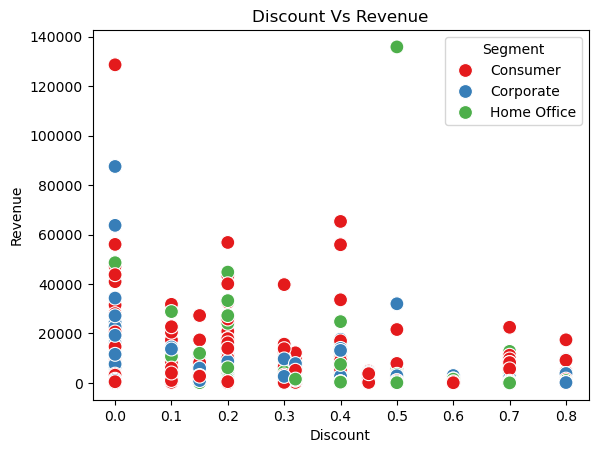

In [48]:
# sns.scatterplot(df['Discount'],df['Revenue'],hue='Segment', palette='Set1', s=100)
sns.scatterplot(x=df['Discount'], y=df['Revenue'], hue=df['Segment'], palette='Set1', s=100)
plt.title("Discount Vs Revenue")
plt.xlabel('Discount')
plt.ylabel('Revenue')

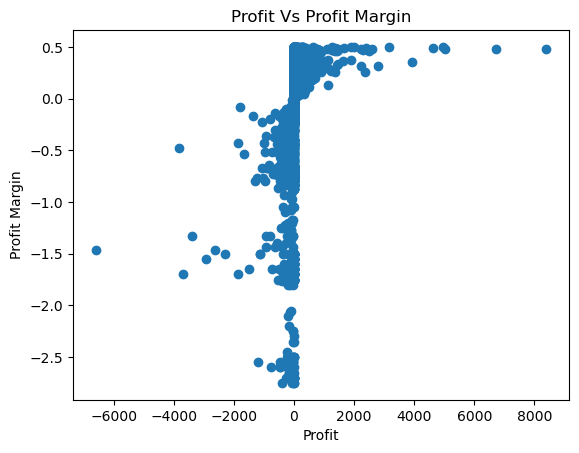

In [49]:
plt.scatter(x = df['Profit'],y = df['Profit Margin'])
plt.title("Profit Vs Profit Margin")
plt.xlabel('Profit')
plt.ylabel('Profit Margin')
plt.show()

In [50]:
df[['Sales','Profit','Discount','Quantity']].corr()

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.477031,-0.027325,0.199681
Profit,0.477031,1.000000,-0.218598,0.065026
Discount,-0.027325,-0.218598,1.000000,0.010030
Quantity,0.199681,0.065026,0.010030,1.000000


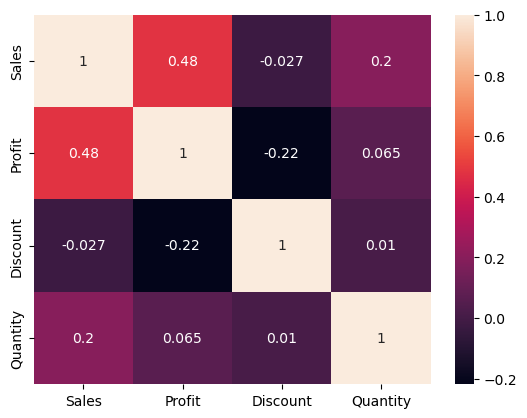

In [51]:
sns.heatmap(df[['Sales','Profit','Discount','Quantity']].corr(), annot=True)
plt.show()

In [52]:
category_summary = df.groupby('Category')[['Sales','Profit']].sum()
category_summary

,Sales,Profit
Category,,
Furniture,732953.6393,16977.7616
Office Supplies,711954.5110,121455.8555
Technology,829874.2550,143621.5801


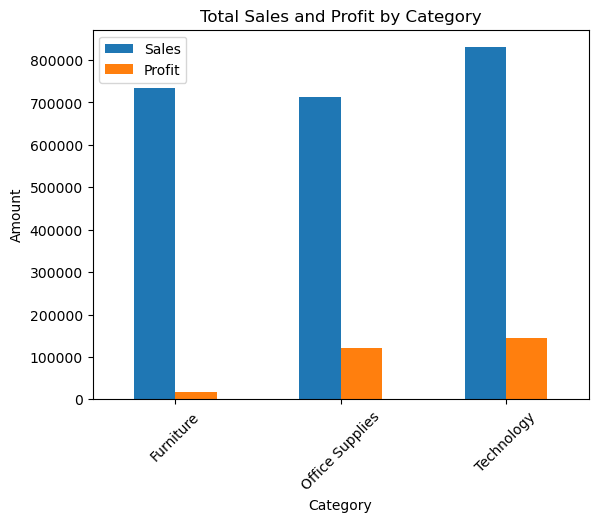

In [53]:
category_summary.plot(kind='bar')
plt.title("Total Sales and Profit by Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

In [54]:
segment_summary = df.groupby('Segment')[['Sales','Profit']].sum()
segment_summary

,Sales,Profit
Segment,,
Consumer,1.157764e+06,133721.9894
Corporate,6.916923e+05,89488.8217
Home Office,4.253263e+05,58844.3861


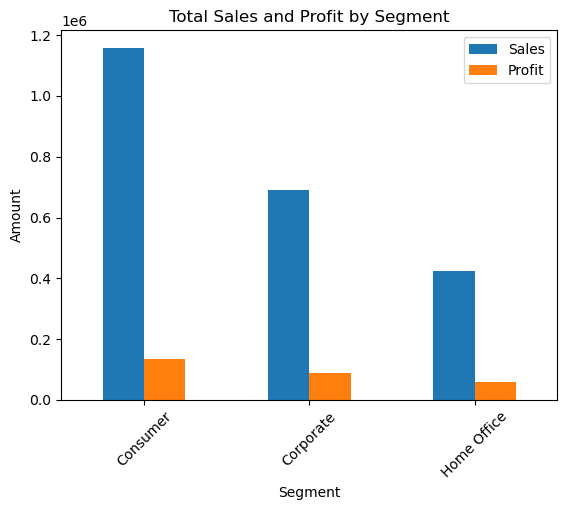

In [55]:
segment_summary.plot(kind='bar')
plt.title("Total Sales and Profit by Segment")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

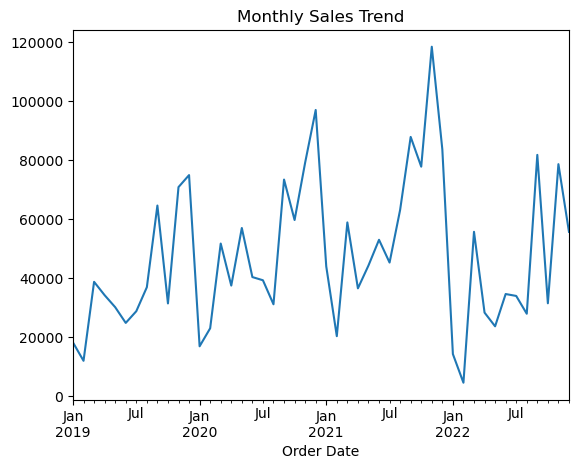

In [56]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

## Final Business Insights

1. Revenue is highly concentrated — median order value is only $54 vs mean of  $229.
2. Discounts above 20% lead to negative average profit (confirmed by Discount Bucket analysis).
3. Technology generates highest sales but Furniture shows lowest profit margins.
4. Consumer segment drives the most orders but Corporate has stronger margins.